# Demand forecasting with a censored likelihood

Recorded sales understate demand in two ways. A stockout writes a genuine
demand day as zero. A shelf that cannot hold any more stops the register at
a capacity cap, so the recorded number is a lower bound. A model trained on
that series forecasts sales. Replenishment needs a forecast of demand.

This notebook simulates an AR(2) with weekly seasonality, censors it, and
fits one `ForecastingModel` whose likelihood knows the difference: a normal
density below the cap, survival mass at the cap, and no contribution from
stockout days. The same recursion filters the training history and simulates
the horizon. It is a port of the
[numpyro-forecast censored-demand example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/censored_demand.html),
which itself ports
[Demand Forecasting with Censored Likelihood](https://juanitorduz.github.io/demand/).

The sibling examples treat availability differently.
[Intermittent demand](intermittent_demand.ipynb) separates occurrence from
size. [Retail stockouts](retail_stockouts.ipynb) scales the mean by a floored
availability factor. Here the censoring point is known, so the likelihood
models the mechanism instead of its average effect.

## Prepare notebook

In [1]:
import os
from functools import partial

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from IPython.display import display
from jax import random

from pymc_forecast import (
    ForecastingModel,
    HMCForecaster,
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    evaluate_forecast,
    fourier_features,
    ssoe,
)

SMOKE = os.getenv("PYMC_FORECAST_SMOKE_TEST") == "1"
SEED = 42
DRAWS, TUNE, CHAINS = (25, 25, 1) if SMOKE else (1000, 1000, 4)
N_PERIODS = 48 if SMOKE else 180
HORIZON = 12 if SMOKE else 30
CAPACITY = np.float32(2.2)
HDI_PROB = 0.94

az.style.use("arviz-darkgrid")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%config InlineBackend.figure_format = "retina"
print(
    "Execution mode:",
    "CI smoke check; do not interpret fit quality" if SMOKE else "full example",
)
print("jax", jax.__version__)

Execution mode: full example
jax 0.11.2


## Simulate demand, sales, and the register

Latent demand is an AR(2) plus a weekly sinusoid, clipped at zero. Sales are
demand minus friction, never above demand and never negative. Observed sales
are zero when the product is off the shelf and capped at 2.2 otherwise.

$$
d_t = \max(0, \phi_1 d_{t-1} + \phi_2 d_{t-2} + \gamma \sin(2\pi t / 7)
+ \alpha + \varepsilon^d_t)
$$

$$
s_t = \max(0, \min(d_t + \varepsilon^s_t - \delta, d_t)), \qquad
y_t = \min(a_t s_t, 2.2)
$$

The censoring indicator is $c_t = 1\{y_t = 2.2\}$. Equality is safe here
because the simulation's minimum returns the cap bit-exactly. The seed and
the split match the upstream notebook, so the 180-day series has the same
49 stockouts and 36 capped days.

In [2]:
def generate_demand_sales(key, n_periods=180):
    """Simulate latent demand, uncapped sales, observed sales, and availability."""
    key_demand, key_sales, key_avail = random.split(key, 3)
    noise_demand = 0.3 * random.normal(key_demand, (n_periods,))
    noise_sales = 0.5 * random.normal(key_sales, (n_periods,))
    available = random.bernoulli(key_avail, 0.8, (n_periods,)).astype(jnp.float32)
    t_grid = jnp.arange(n_periods, dtype=jnp.float32)

    def step(carry, xs):
        previous_1, previous_2 = carry
        t, eps_demand, eps_sales = xs
        seasonal = 0.6 * jnp.sin(2 * jnp.pi * t / 7)
        demand = jnp.clip(
            0.6 * previous_1 + 0.3 * previous_2 + seasonal + 0.2 + eps_demand,
            min=0.0,
        )
        sales = jnp.clip(jnp.minimum(demand + eps_sales - 0.25, demand), min=0.0)
        return (demand, previous_1), (demand, sales)

    init = (jnp.float32(2.0), jnp.float32(2.0))
    _, (demand, sales) = jax.lax.scan(step, init, (t_grid, noise_demand, noise_sales))
    sales_obs = jnp.minimum(available * sales, CAPACITY)
    censored = (sales_obs == CAPACITY).astype(jnp.float32)
    return {
        "demand": np.asarray(demand),
        "sales": np.asarray(sales),
        "sales_obs": np.asarray(sales_obs),
        "available": np.asarray(available),
        "censored": np.asarray(censored),
    }


key = random.PRNGKey(SEED)
_, subkey = random.split(key)
full = generate_demand_sales(subkey, 180)
n_stockout = int((1 - full["available"]).sum())
n_censored = int(full["censored"].sum())
print(f"full series stockouts: {n_stockout}; capacity-censored days: {n_censored}")
assert n_stockout == 49
assert n_censored == 36

series = {name: values[:N_PERIODS] for name, values in full.items()}
n_train = N_PERIODS - HORIZON
time = np.arange(N_PERIODS)
print(
    f"window: {N_PERIODS} days, train {n_train}, horizon {HORIZON}; "
    f"train stockouts {int((1 - series['available'][:n_train]).sum())}, "
    f"train capped {int(series['censored'][:n_train].sum())}, "
    f"test peaks {int((series['demand'][n_train:] > CAPACITY).sum())}"
)
assert int((1 - series["available"][:n_train]).sum()) >= 1
assert int(series["censored"][:n_train].sum()) >= 1
assert int((series["demand"][n_train:] > CAPACITY).sum()) >= 1

full series stockouts: 49; capacity-censored days: 36
window: 180 days, train 150, horizon 30; train stockouts 36, train capped 32, test peaks 10


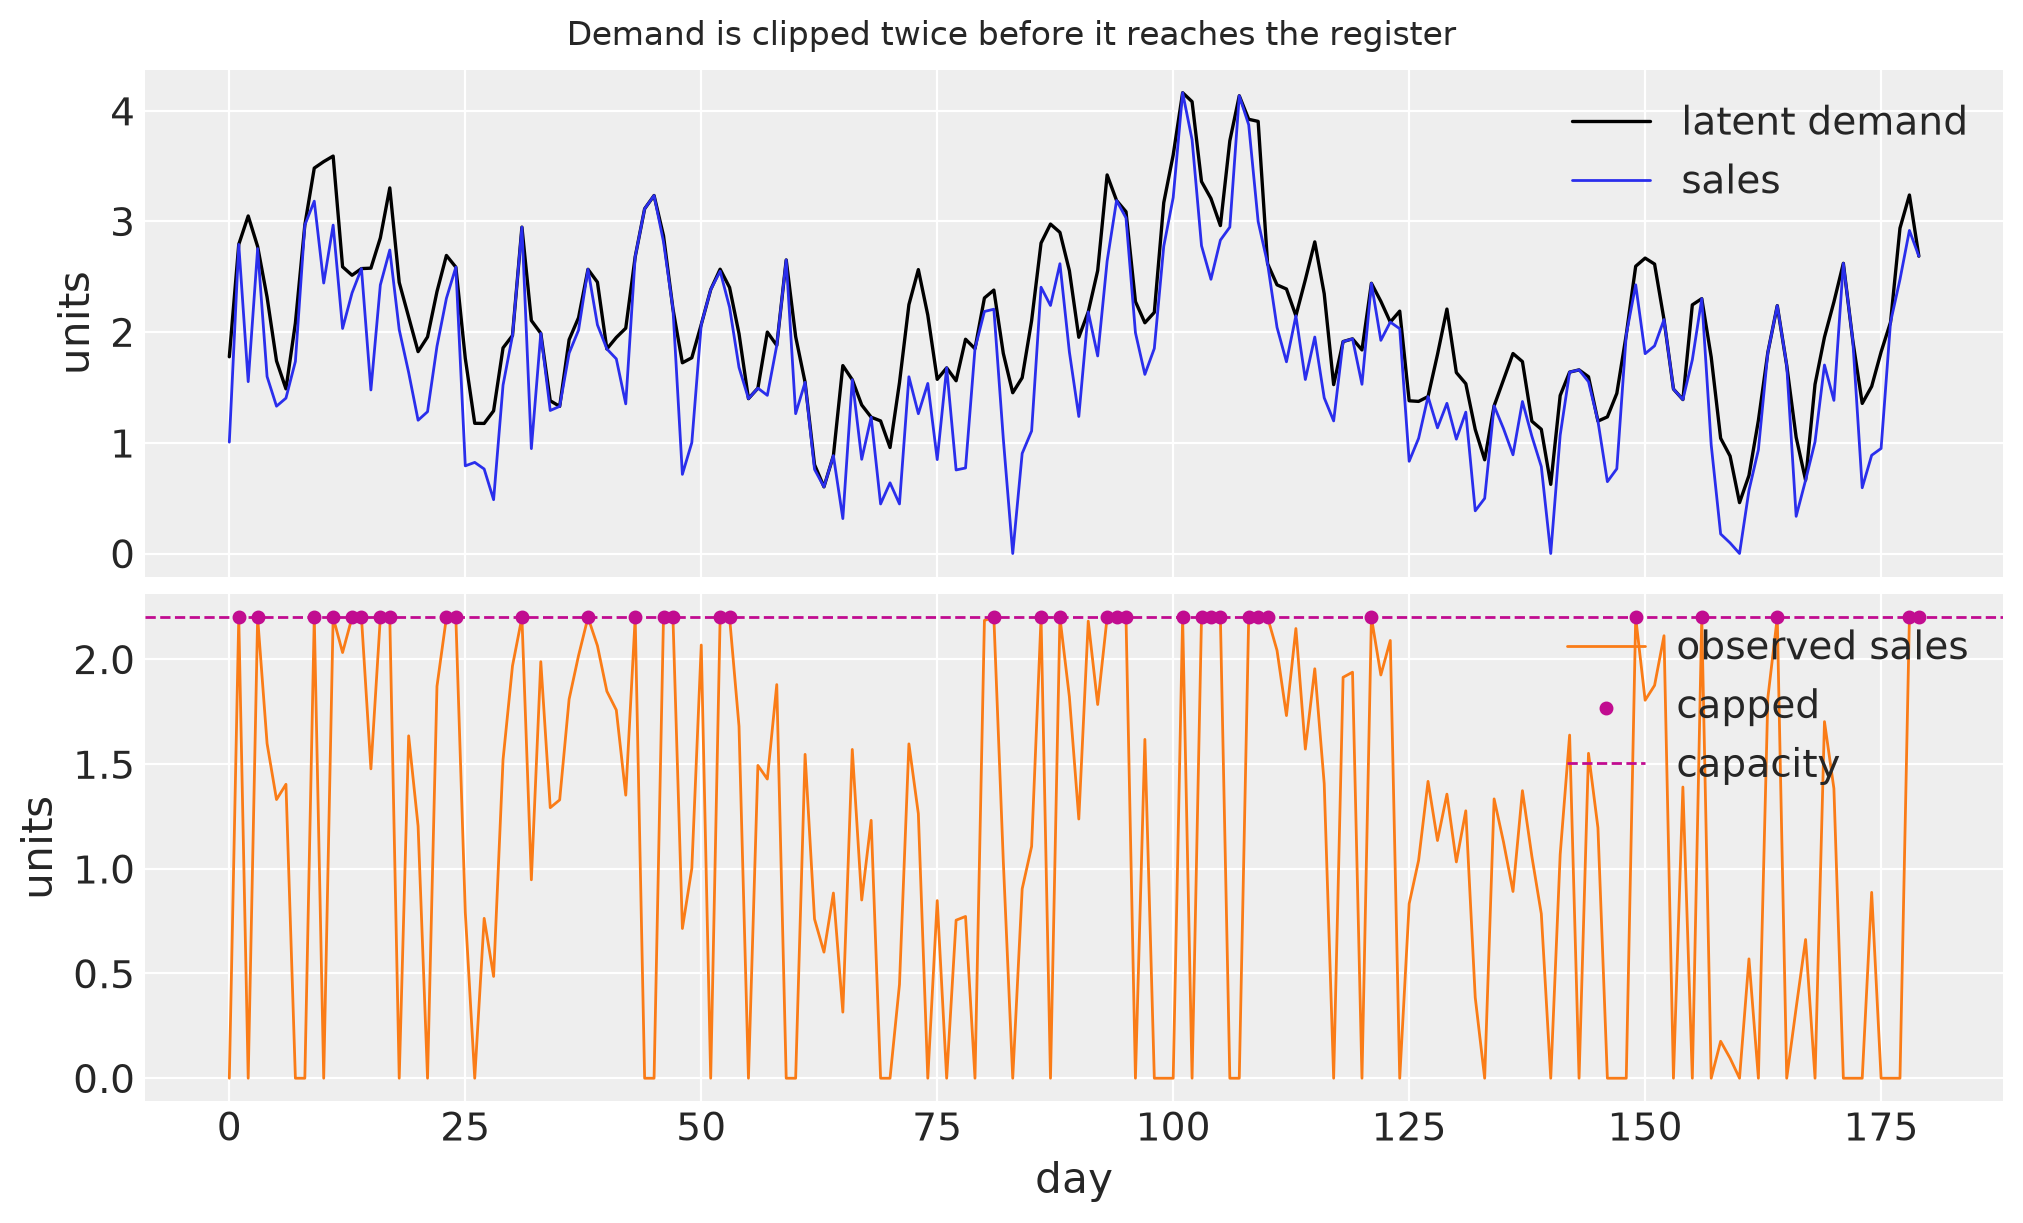

In [3]:
fig, (ax_top, ax_bot) = plt.subplots(nrows=2, sharex=True, figsize=(10, 6), layout="constrained")
ax_top.plot(time, series["demand"], color="black", lw=1.2, label="latent demand")
ax_top.plot(time, series["sales"], color="C0", lw=1, label="sales")
ax_top.legend(loc="upper right")
ax_top.set(ylabel="units")
ax_bot.plot(time, series["sales_obs"], color="C1", lw=1, label="observed sales")
capped = series["censored"] == 1
ax_bot.scatter(
    time[capped],
    series["sales_obs"][capped],
    color="C3",
    s=16,
    zorder=5,
    label="capped",
)
ax_bot.axhline(float(CAPACITY), color="C3", ls="--", lw=1, label="capacity")
ax_bot.legend(loc="upper right")
ax_bot.set(xlabel="day", ylabel="units")
fig.suptitle("Demand is clipped twice before it reaches the register")
plt.show()

## Covariates are the scenario

The last 30 days are the test window (12 in the CI smoke check). Covariates
cover the whole horizon. Column order is part of the model contract:
availability, the censoring indicator, then weekly Fourier terms (sine, then
cosine). Future rows are an explicit scenario: on the shelf, and not capped.
The model reads those rows. It does not hard-code the padding, so a different
scenario is a different covariate tensor rather than an edit to the class.

The naive baseline below is the same class with the censoring column set to
zero. Stockouts stay masked. Only the cap changes, from a lower bound to a
pretend exact observation of 2.2.

In [4]:
def build_inputs(observed, available, censored, horizon):
    """Stack availability, censoring, and Fourier terms. Future rows are the scenario."""
    n_periods = len(observed)
    n_observed = n_periods - horizon
    index = np.arange(n_periods)
    fourier = fourier_features(index, period=7.0, num_terms=2).rename(fourier="input")

    def channel(name, values):
        column = np.asarray(values, dtype=float)[:, None]
        return xr.DataArray(column, dims=("time", "input"), coords={"time": index, "input": [name]})

    availability = channel("availability", np.where(index < n_observed, available, 1.0))
    capped = channel("censored", np.where(index < n_observed, censored, 0.0))
    return xr.concat([availability, capped, fourier], dim="input")


inputs = build_inputs(series["sales_obs"], series["available"], series["censored"], HORIZON)
sales_obs = xr.DataArray(series["sales_obs"], dims="time", coords={"time": time})
train = sales_obs.isel(time=slice(n_train))
assert tuple(str(v) for v in inputs.coords["input"].values) == (
    "availability",
    "censored",
    "sin_1",
    "sin_2",
    "cos_1",
    "cos_2",
)
future = inputs.isel(time=slice(n_train, None))
assert np.all(future.sel(input="availability").values == 1.0)
assert np.all(future.sel(input="censored").values == 0.0)

## One recursion, a censored likelihood

The one-step mean is an AR(2) on filtered lags plus the Fourier term.

$$
\hat{y}_t = \alpha + \phi_1 \tilde{y}_{t-1} + \phi_2 \tilde{y}_{t-2} + f_t^\top \beta
$$

A stockout zero must not enter the lag. Neither must a capped day be treated
as if demand stopped at the cap. The filter passes a clean observation
through, floors a capped day at the prediction, and substitutes the
prediction on a stockout. The carry is then clipped at zero, and shifted:

$$
\tilde{y}_t = \max\left(0,\; a_t\big[(1-c_t) y_t + c_t \max(y_t, \hat{y}_t)\big]
+ (1-a_t)\hat{y}_t\right)
$$

The likelihood matches NumPyro's `RightCensoredDistribution`. Below the cap
it is the normal density. At the cap it is the survival $P(Y \ge y_t)$, using
the recorded value as the bound rather than a second equality check against
2.2. The first two steps run on placeholder lags (the first observation,
twice) and, like stockouts, contribute nothing. `pm.Censored` is the wrong
registration here: its random draw is clipped, so in-sample predictive bands
could not rise above the cap. A `CustomDist` keeps the normal draw and
replaces only the log probability.

`ssoe` registers future errors and nothing else. The class registers `obs`,
the in-sample mean `mu`, and, when the covariate horizon is longer than the
data, a nonnegative `forecast`. The package reserves `mu` for that predictor,
so the intercept is `intercept`. Scan cannot close over random variables, so
the coefficients travel in `params`.

In [5]:
N_ORDER = 2
INPUT_LABELS = ("availability", "censored", "sin_1", "sin_2", "cos_1", "cos_2")


def filtered_lag(y, pred, available, censored):
    """Carry a demand lag through stockouts and capped days."""
    on_shelf = pt.switch(pt.eq(censored, 1), pt.maximum(y, pred), y)
    carried = pt.switch(pt.eq(available, 1), on_shelf, pred)
    return pt.maximum(carried, 0.0)


def censored_logp(value, mu, sigma, censored, valid):
    """Normal density, or survival at the recorded value, or zero if invalid."""
    normal = pm.logp(pm.Normal.dist(mu, sigma), value)
    # Reflect the Normal so its log-CDF evaluates the survival tail directly.
    survival = pm.logcdf(pm.Normal.dist(-mu, sigma), -value)
    point = pt.switch(censored, survival, normal)
    return pt.switch(valid, point, 0.0)


class CensoredAR2(ForecastingModel):
    """AR(2) on filtered lags with a right-censored normal likelihood."""

    def model(self, covariates, data=None):
        labels = tuple(str(v) for v in covariates.coords["input"].values)
        if labels != INPUT_LABELS:
            raise ValueError(f"expected inputs {INPUT_LABELS}, got {labels}")
        horizon = self.horizon
        observed = horizon.data
        pm.modelcontext(None).add_coord("fourier", list(INPUT_LABELS[2:]))
        intercept = pm.Normal("intercept", 1.0, 1.0)
        phi_1 = pm.Normal("phi_1", 0.0, 1.0)
        phi_2 = pm.Normal("phi_2", 0.0, 1.0)
        sigma = pm.HalfNormal("sigma", 1.0)
        beta = pm.Normal("beta_seasonal", 0.0, 1.0, dims="fourier")

        def mean(state, x, intercept, phi_1, phi_2, beta):
            return intercept + phi_1 * state[0] + phi_2 * state[1] + pt.dot(x[2:], beta)

        def update(state, y, _error, x, intercept, phi_1, phi_2, beta):
            lag_1, _lag_2 = state
            pred = mean(state, x, intercept, phi_1, phi_2, beta)
            return filtered_lag(y, pred, x[0], x[1]), lag_1

        y0 = float(observed.values[0])
        result = ssoe(
            horizon,
            "eps",
            None,
            (y0, y0),
            mean,
            update,
            pm.Normal.dist(0, sigma),
            xs=covariates,
            params=(intercept, phi_1, phi_2, beta),
        )
        train_x = covariates.sel(time=horizon.time)
        censored = pt.as_tensor_variable(train_x.sel(input="censored").values)
        available = pt.as_tensor_variable(train_x.sel(input="availability").values)
        valid = pt.and_(pt.arange(horizon.t_obs) >= N_ORDER, pt.eq(available, 1))

        def logp(value, mu, sigma):
            return censored_logp(value, mu, sigma, censored, valid)

        pm.CustomDist(
            "obs",
            result.mu,
            sigma,
            dist=lambda mu, sigma, size: pm.Normal.dist(mu, sigma, size=size),
            logp=logp,
            observed=np.asarray(observed.transpose("time").values, dtype=float),
            dims="time",
        )
        pm.Deterministic("mu", result.mu, dims="time")
        if horizon.future:
            pm.Deterministic("mu_future", result.mu_future, dims="time_future")
            pm.Deterministic("forecast", pt.maximum(result.y_future, 0.0), dims="time_future")

## Fit

Eight parameters, a deterministic filter, and a survival term. Four chains of
1,000 warmup and 1,000 draws, `target_accept=0.9`. Sampling is sequential
because JAX is already imported; forking the process from a multithreaded JAX
runtime is unsafe. The smoke check uses one short chain and does not recover
parameters.

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [intercept, phi_1, phi_2, sigma, beta_seasonal]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.295,0.138,0.047,0.56,2039,2150,1.00,0.0031,0.0025
phi_1,0.458,0.113,0.25,0.68,1801,1980,1.00,0.0027,0.0019
phi_2,0.409,0.115,0.2,0.63,1768,2113,1.01,0.0028,0.0019
sigma,0.545,0.047,0.46,0.63,2404,2272,1.00,0.00098,0.00082
beta_seasonal[sin_1],0.508,0.085,0.34,0.66,2402,2682,1.00,0.0017,0.0014
beta_seasonal[sin_2],-0.019,0.085,-0.18,0.13,2736,2583,1.00,0.0016,0.0014
beta_seasonal[cos_1],-0.178,0.084,-0.34,-0.025,2001,2075,1.00,0.0019,0.0012
beta_seasonal[cos_2],-0.073,0.088,-0.24,0.095,3064,2663,1.00,0.0016,0.0015


/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_69780/1384402765.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


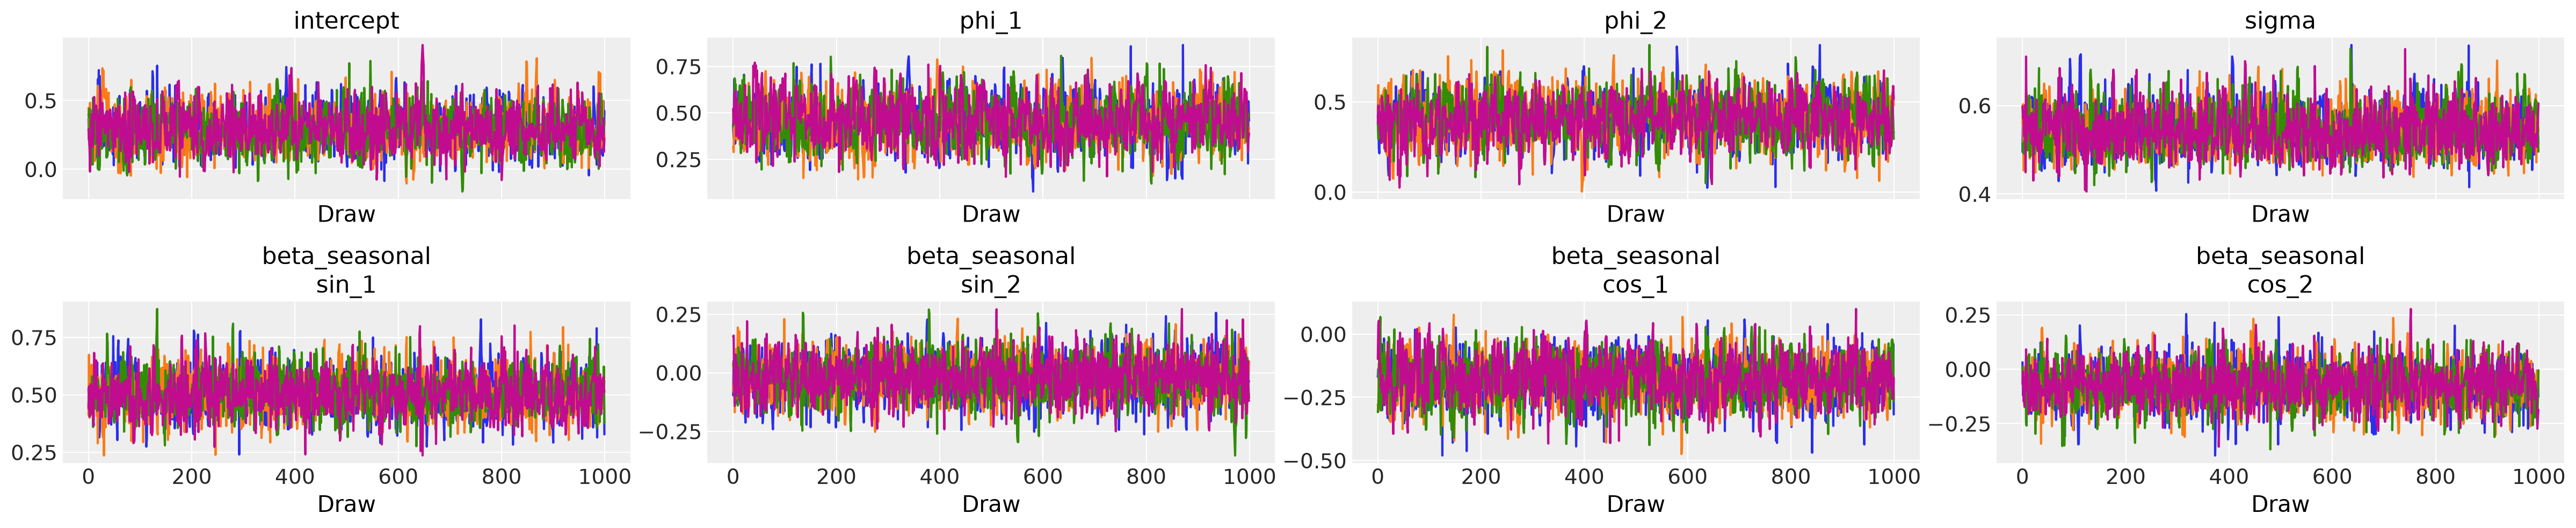

In [6]:
SAMPLE_KWARGS = {"target_accept": 0.9, "cores": 1}
censored = HMCForecaster(
    CensoredAR2(),
    train,
    inputs.isel(time=slice(n_train)),
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    random_seed=SEED,
    progressbar=False,
    sample_kwargs=SAMPLE_KWARGS,
)
assert "eps_future" not in censored.idata.posterior
summary = az.summary(
    censored.idata,
    var_names=["intercept", "phi_1", "phi_2", "sigma", "beta_seasonal"],
)
display(summary)

# compact=True is ArviZ 0.x only; 1.x rejects the keyword.
az.plot_trace(
    censored.idata,
    var_names=["intercept", "phi_1", "phi_2", "sigma", "beta_seasonal"],
)
plt.tight_layout()
plt.show()

## In-sample bands are demand-scale sales

Posterior predictive draws come from the uncensored normal, so they may
exceed the cap and dip below zero. That is the point of not using
`pm.Censored`. The first two steps are placeholder lags and are dropped.
Gray bands are stockouts: the filter carries the prediction instead of the
recorded zero. The black line is latent demand, which the likelihood never
saw. Sales sit below it by the friction term.

Sampling: [obs]


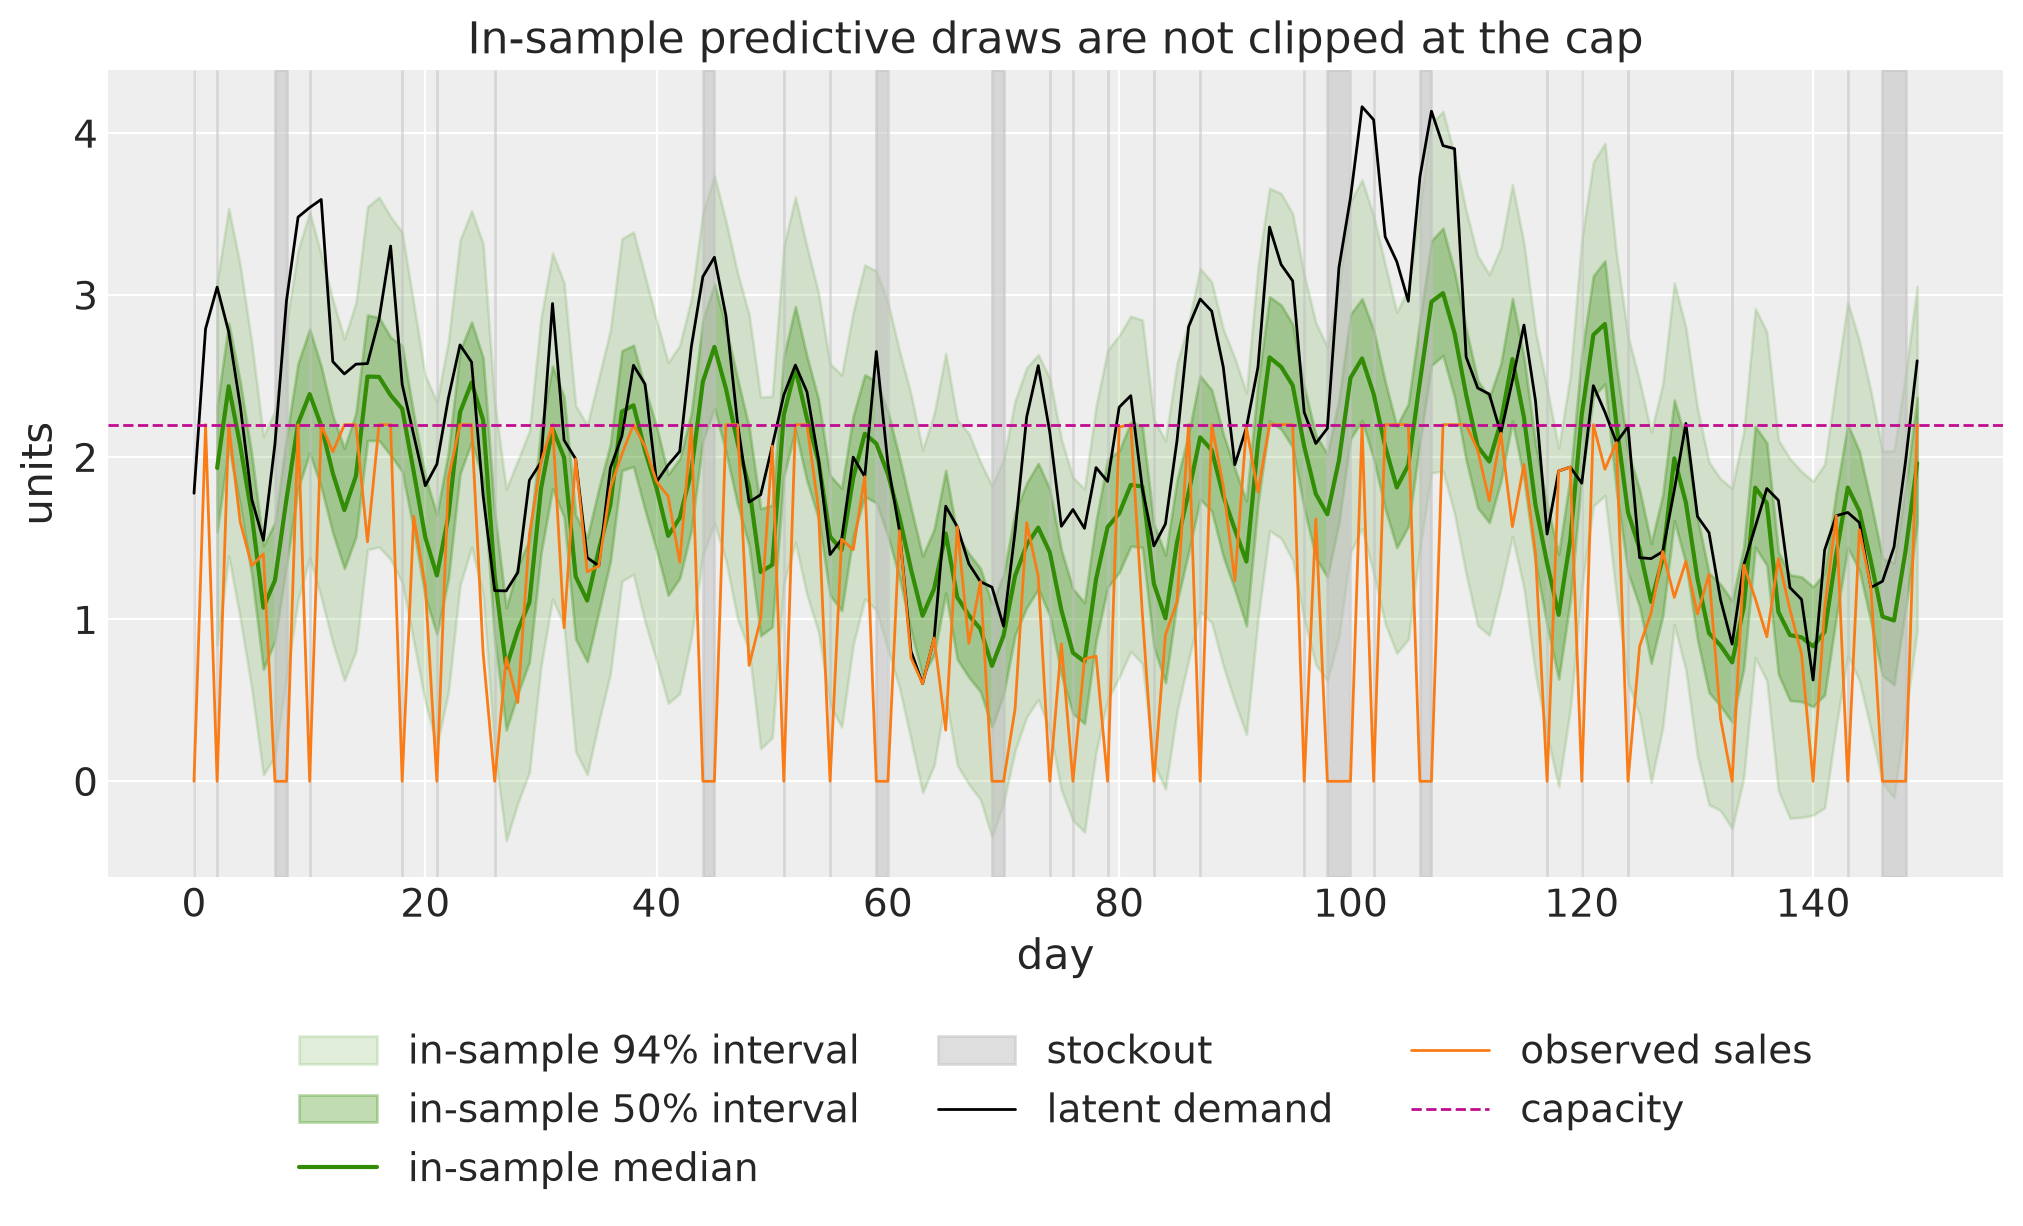

In [7]:
def central_bands(ax, samples, x, color, label):
    """Plot the median and the central 50% and 94% intervals."""
    stacked = samples.stack(sample=("chain", "draw"))
    quantiles = stacked.quantile([0.03, 0.25, 0.5, 0.75, 0.97], dim="sample")
    x = np.asarray(x)
    band = {q: np.asarray(quantiles.sel(quantile=q)) for q in (0.03, 0.25, 0.5, 0.75, 0.97)}
    ax.fill_between(
        x, band[0.03], band[0.97], color=color, alpha=0.15, label=f"{label} 94% interval"
    )
    ax.fill_between(
        x, band[0.25], band[0.75], color=color, alpha=0.3, label=f"{label} 50% interval"
    )
    ax.plot(x, band[0.5], color=color, lw=1.5, label=f"{label} median")


in_sample = censored.predict_in_sample(posterior=censored.idata, random_seed=SEED + 1)
fig, ax = plt.subplots()
kept = slice(N_ORDER, None)
# obs is the training window; time is the full series, including the horizon.
in_sample_obs = in_sample.posterior_predictive.obs.isel(time=kept)
train_time = time[:n_train][kept]
assert in_sample_obs.sizes["time"] == len(train_time)
central_bands(ax, in_sample_obs, train_time, "C2", "in-sample")
stockout = series["available"][:n_train] == 0
ax.fill_between(
    time[:n_train],
    0,
    1,
    where=stockout,
    transform=ax.get_xaxis_transform(),
    color="0.75",
    alpha=0.5,
    step="mid",
    label="stockout",
)
ax.plot(time[:n_train], series["demand"][:n_train], color="black", lw=1, label="latent demand")
ax.plot(time[:n_train], series["sales_obs"][:n_train], color="C1", lw=1, label="observed sales")
ax.axhline(float(CAPACITY), color="C3", ls="--", lw=1, label="capacity")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
ax.set(title="In-sample predictive draws are not clipped at the cap", xlabel="day", ylabel="units")
plt.show()

## Forecast the uncensored scenario

`forecast` rebuilds the model on the full covariate horizon and draws
`eps_future` from the noise distribution. Those errors are not in the
posterior. The registered forecast clips each simulated trajectory at zero.
Score it against latent demand, the series the model never saw. Passing
`posterior=idata` uses every MCMC draw. The default of 100 would not be the
comparison this notebook is making.

Sampling: [eps_future]


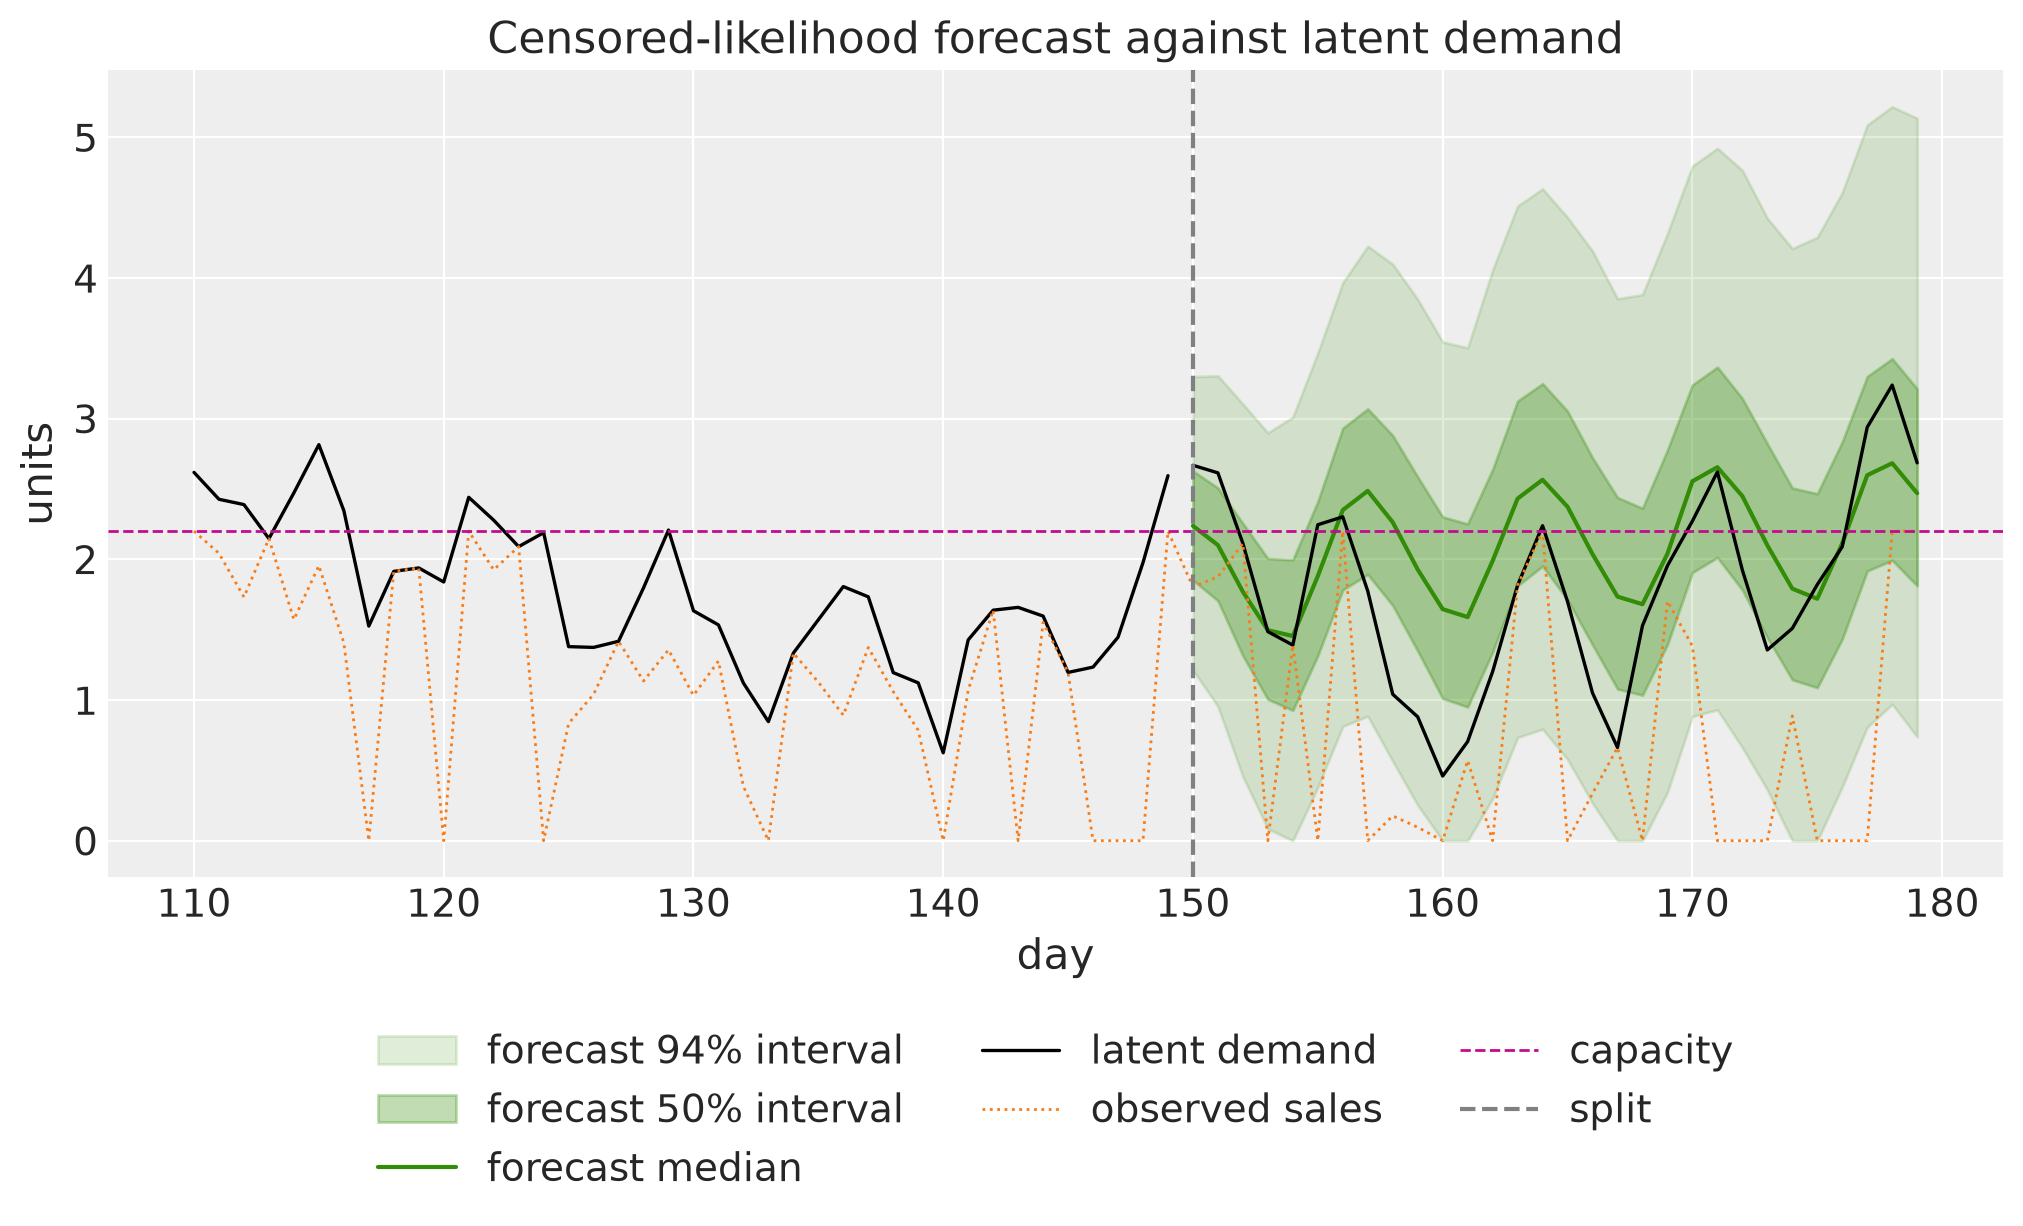

In [8]:
prediction = censored.forecast(covariates=inputs, posterior=censored.idata, random_seed=SEED + 2)
forecast = prediction.predictions.forecast
assert forecast.dims == ("chain", "draw", "time_future")
assert forecast.sizes["time_future"] == HORIZON
demand_future = (
    xr.DataArray(series["demand"], dims="time", coords={"time": time})
    .isel(time=slice(n_train, None))
    .rename(time="time_future")
)
sales_future = sales_obs.isel(time=slice(n_train, None)).rename(time="time_future")
assert np.array_equal(forecast.time_future.values, demand_future.time_future.values)

fig, ax = plt.subplots()
central_bands(ax, forecast, forecast.time_future.values, "C2", "forecast")
history_start = max(0, n_train - 40)
ax.plot(
    time[history_start:n_train],
    series["demand"][history_start:n_train],
    color="black",
    lw=1.2,
    label="latent demand",
)
ax.plot(forecast.time_future.values, demand_future.values, color="black", lw=1.2)
ax.plot(
    time[history_start:],
    series["sales_obs"][history_start:],
    color="C1",
    ls=":",
    lw=1,
    label="observed sales",
)
ax.axhline(float(CAPACITY), color="C3", ls="--", lw=1, label="capacity")
ax.axvline(n_train, color="0.5", ls="--", label="split")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
ax.set(title="Censored-likelihood forecast against latent demand", xlabel="day", ylabel="units")
plt.show()

## The naive model treats the cap as data

Zero the censoring column and refit. The forecast must be rebuilt on that
same tensor. Replaying the naive posterior through the original covariates
would filter the training lags with a censoring rule the fit never saw.

In [9]:
naive_inputs = inputs.copy(deep=True)
naive_inputs.loc[{"input": "censored"}] = 0.0
naive = HMCForecaster(
    CensoredAR2(),
    train,
    naive_inputs.isel(time=slice(n_train)),
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    random_seed=SEED + 3,
    progressbar=False,
    sample_kwargs=SAMPLE_KWARGS,
)
naive_summary = az.summary(
    naive.idata,
    var_names=["intercept", "phi_1", "phi_2", "sigma", "beta_seasonal"],
)
display(naive_summary)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [intercept, phi_1, phi_2, sigma, beta_seasonal]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 26 seconds.


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.448,0.131,0.21,0.69,3149,2756,1.00,0.0023,0.002
phi_1,0.407,0.095,0.23,0.59,2531,2719,1.00,0.0019,0.0014
phi_2,0.317,0.097,0.13,0.49,2541,2478,1.00,0.0019,0.0015
sigma,0.434,0.0301,0.38,0.49,3369,2693,1.00,0.00052,0.0005
beta_seasonal[sin_1],0.345,0.059,0.24,0.46,4041,3103,1.00,0.00093,0.00094
beta_seasonal[sin_2],0.013,0.061,-0.1,0.13,4331,2615,1.00,0.00092,0.001
beta_seasonal[cos_1],-0.159,0.061,-0.27,-0.041,2962,2410,1.00,0.0011,0.00091
beta_seasonal[cos_2],-0.086,0.063,-0.2,0.032,4567,2868,1.00,0.00093,0.0011


Sampling: [eps_future]


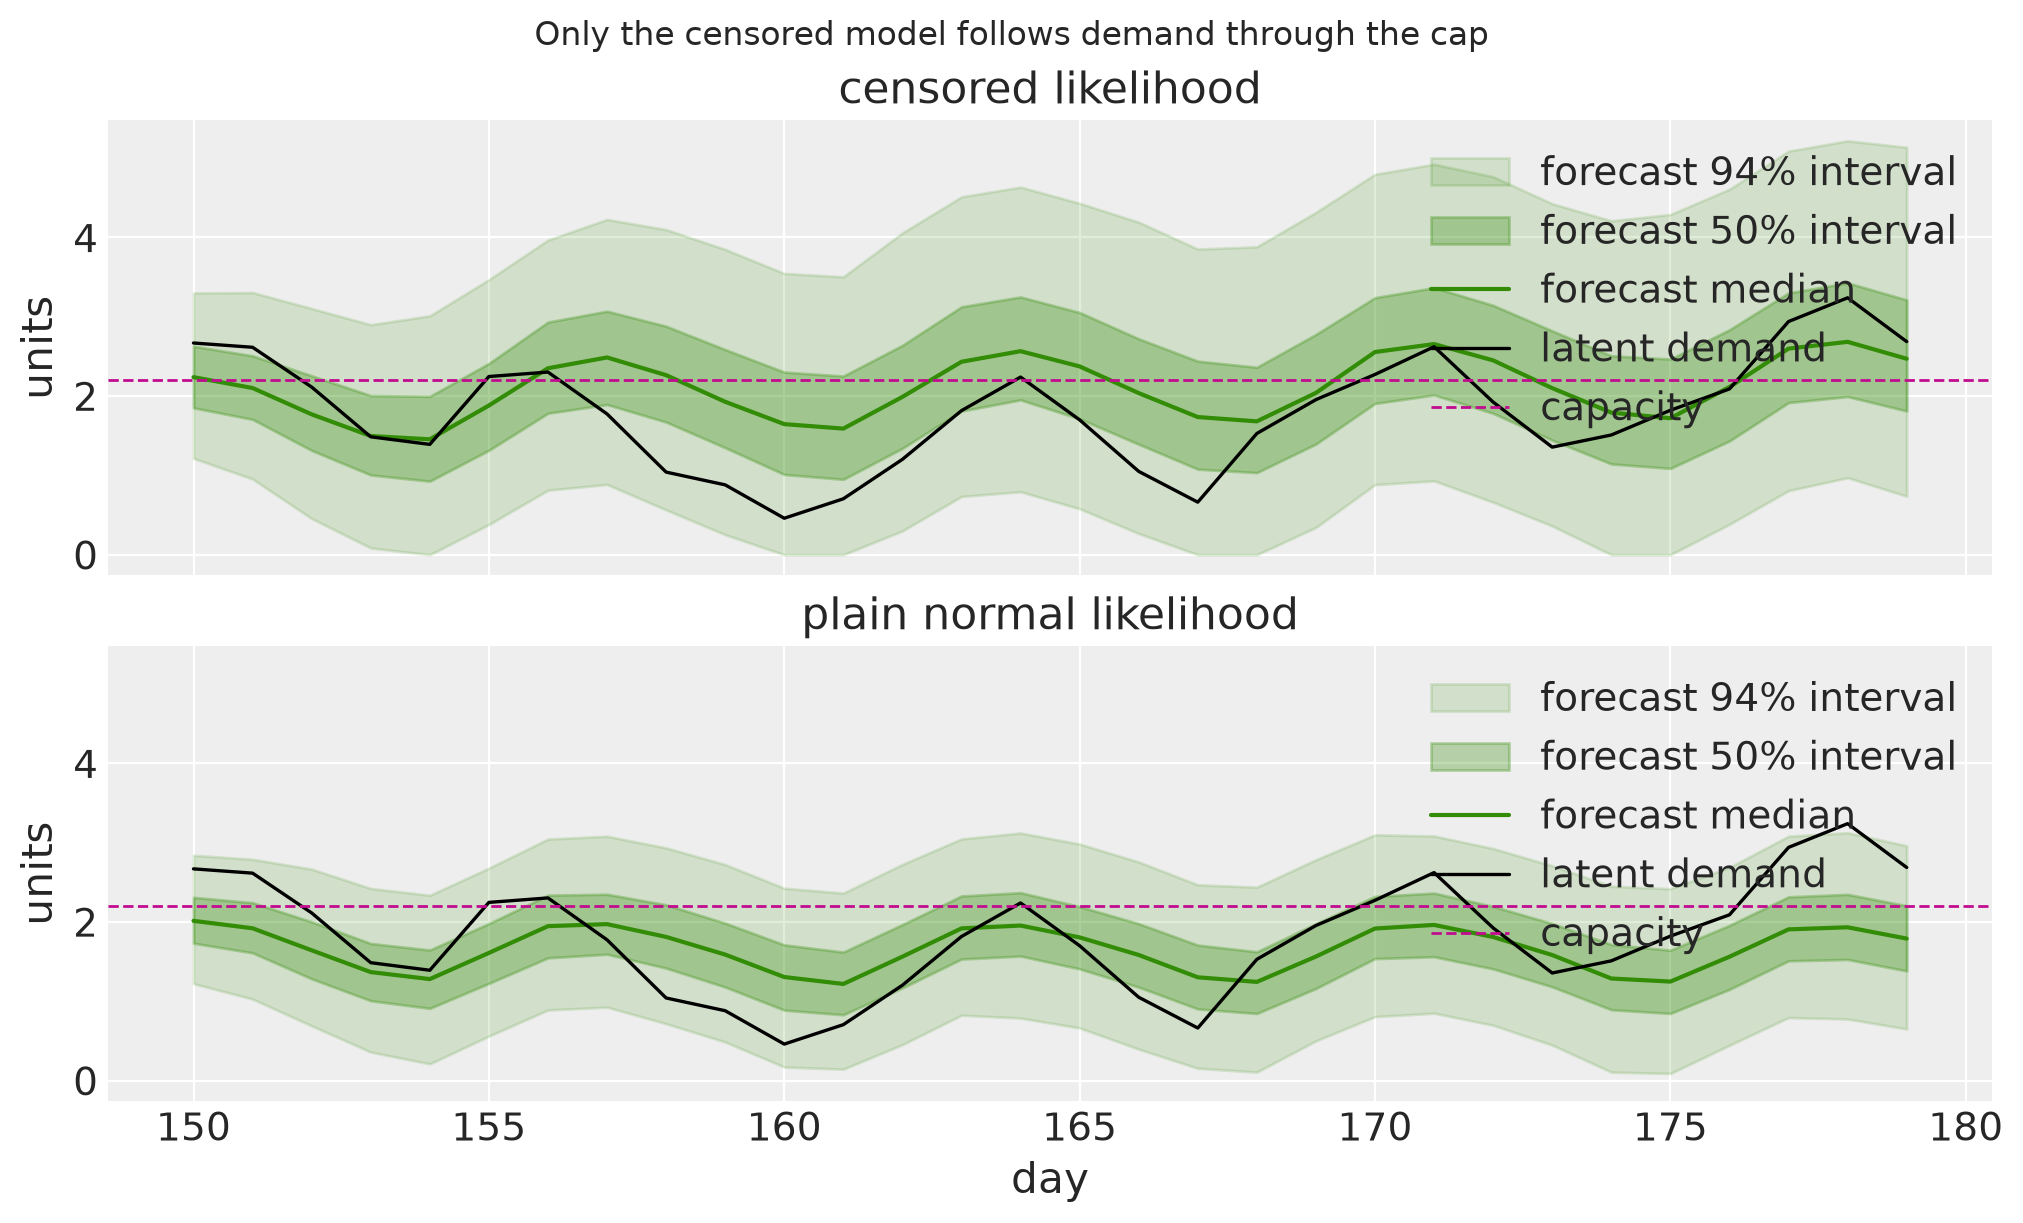

In [10]:
naive_prediction = naive.forecast(
    covariates=naive_inputs,
    posterior=naive.idata,
    random_seed=SEED + 4,
)
naive_forecast = naive_prediction.predictions.forecast
fig, axes = plt.subplots(nrows=2, sharex=True, sharey=True, figsize=(10, 6), layout="constrained")
for ax, draws, title in (
    (axes[0], forecast, "censored likelihood"),
    (axes[1], naive_forecast, "plain normal likelihood"),
):
    central_bands(ax, draws, draws.time_future.values, "C2", "forecast")
    ax.plot(
        draws.time_future.values,
        demand_future.values,
        color="black",
        lw=1.2,
        label="latent demand",
    )
    ax.axhline(float(CAPACITY), color="C3", ls="--", lw=1, label="capacity")
    ax.set(title=title, ylabel="units")
    ax.legend(loc="upper right")
axes[1].set(xlabel="day")
fig.suptitle("Only the censored model follows demand through the cap")
plt.show()

## Evaluation

Two truths, because they answer different questions. Latent demand is the
planning quantity, known here only because the series was simulated. Observed
sales are what a transaction table would offer, and they are themselves gated
and capped, so a demand forecast is penalized for being right. Coverage is
the central interval, not an HDI. On peak days — latent demand above the cap —
the naive mean should stay under the cap it mistook for data.

In [11]:
metrics = {
    "mae": eval_mae,
    "rmse": eval_rmse,
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}
rows = {
    ("censored likelihood", "latent demand"): evaluate_forecast(
        forecast, demand_future, metrics=metrics
    ),
    ("plain normal likelihood", "latent demand"): evaluate_forecast(
        naive_forecast, demand_future, metrics=metrics
    ),
    ("censored likelihood", "observed sales"): evaluate_forecast(
        forecast, sales_future, metrics=metrics
    ),
    ("plain normal likelihood", "observed sales"): evaluate_forecast(
        naive_forecast, sales_future, metrics=metrics
    ),
}
results = pd.DataFrame(rows).T.round(3)
results.index.names = ["model", "truth"]
display(results)

,,mae,rmse,crps,coverage_50,coverage_94
model,truth,,,,,
censored likelihood,latent demand,0.488,0.639,0.368,0.600,1.000
plain normal likelihood,latent demand,0.490,0.570,0.329,0.467,0.967
censored likelihood,observed sales,1.342,1.631,1.002,0.300,0.600
plain normal likelihood,observed sales,0.993,1.200,0.772,0.300,0.467


In [12]:
peak_times = demand_future.time_future.values[np.asarray(demand_future) > float(CAPACITY)]
print(f"test days with latent demand above the cap: {len(peak_times)} of {HORIZON}")
peak = pd.DataFrame(
    {
        "censored likelihood": evaluate_forecast(
            forecast.sel(time_future=peak_times),
            demand_future.sel(time_future=peak_times),
            metrics=metrics,
        ),
        "plain normal likelihood": evaluate_forecast(
            naive_forecast.sel(time_future=peak_times),
            demand_future.sel(time_future=peak_times),
            metrics=metrics,
        ),
    }
).T.round(3)
peak.index.name = "model"
display(peak)

test days with latent demand above the cap: 10 of 30


,mae,rmse,crps,coverage_50,coverage_94
model,,,,,
censored likelihood,0.311,0.337,0.270,0.8,1.0
plain normal likelihood,0.688,0.746,0.456,0.3,0.9


In [13]:
censored_mean = forecast.mean(("chain", "draw"))
naive_mean = naive_forecast.mean(("chain", "draw"))
print("censored forecast mean max", float(censored_mean.max()))
print("naive forecast mean max", float(naive_mean.max()))
if not SMOKE:
    published = {"intercept": 0.294, "phi_1": 0.447, "phi_2": 0.419, "sigma": 0.543}
    for name, target in published.items():
        estimate = float(summary.loc[name, "mean"])
        if abs(estimate - target) >= 0.08:
            raise AssertionError(f"{name} mean {estimate:.3f} is not within 0.08 of {target}")
    beta_key = next(idx for idx in summary.index if "sin_1" in str(idx))
    beta_sin = float(summary.loc[beta_key, "mean"])
    if abs(beta_sin - 0.506) >= 0.08:
        raise AssertionError(f"sin_1 coefficient {beta_sin:.3f} is not within 0.08 of 0.506")
    if float(summary.loc["sigma", "mean"]) <= float(naive_summary.loc["sigma", "mean"]) + 0.05:
        raise AssertionError("censored sigma should exceed the naive sigma")
    if float(summary["r_hat"].max()) >= 1.05:
        raise AssertionError(f"r_hat {float(summary['r_hat'].max()):.3f} is at least 1.05")
    censored_peak = float(peak.loc["censored likelihood", "mae"])
    naive_peak = float(peak.loc["plain normal likelihood", "mae"])
    if censored_peak >= naive_peak:
        raise AssertionError("censored peak-day MAE should be lower")
    if float(censored_mean.max()) <= float(CAPACITY) or float(naive_mean.max()) >= float(CAPACITY):
        raise AssertionError("only the censored forecast mean should cross the cap")

censored forecast mean max 2.7887307834947457
naive forecast mean max 2.0218151567476768


## What the comparison is saying

Against latent demand, average point error is close. Both models target the
sales scale, which sits below demand by the friction term, and most test days
are below the cap. Calibration and the peaks are where the likelihood
matters. The censored intervals cover at their nominal level. The naive fit
treats every capped day as an exact 2.2, so its mean is pulled down and its
$\sigma$ shrinks. Against observed sales the naive model wins the point
scores, and it should: the test register is gated and capped too. Scoring
recorded sales rewards a model that repeats the corruption.

On days when latent demand exceeds the cap, the censored forecast follows
demand across the line. The naive forecast mean stays under the cap. That is
the operational difference.

| Example | What the data record | What the model does |
| --- | --- | --- |
| [Intermittent demand](intermittent_demand.ipynb) | Occurrence or not | Occurrence times size |
| [Retail stockouts](retail_stockouts.ipynb) | Availability share | Floored mean factor |
| This notebook | Cap and off-shelf flag | Survival at the cap |

The upstream availability-TSB example freezes a probability recursion on
off-shelf days. This package does not include that notebook. The same idea,
an update gate plus a masked likelihood, is what `ssoe` expects the caller to
write. The mechanisms compose: a fractional availability factor for partial
days, and a survival term where the shelf capacity is known.

## Next steps

- Replace $\max(y_t, \hat{y}_t)$ with the censored conditional mean
  $\hat{y}_t + \sigma \varphi(z_t) / (1 - \Phi(z_t))$.
- Let the cap vary by day, from inventory. The likelihood already censors at
  the recorded value, so only the covariate changes.
- Use a nonnegative observation distribution so the in-sample bands do not
  put mass on negative sales.
- Replace the single split with `backtest`, as in the
  [ARMA example](arma.ipynb).

## References

- Orduz, J. [Demand Forecasting with Censored Likelihood](https://juanitorduz.github.io/demand/).
- The [upstream notebook](https://juanitorduz.github.io/numpyro_forecast/docs/examples/censored_demand.html)
  this example ports.
- Tobin, J. (1958). [Estimation of Relationships for Limited Dependent Variables](https://doi.org/10.2307/1907382).
  Econometrica, 26(1), 24-36.
- NumPyro's [censored distributions](https://num.pyro.ai/en/stable/distributions.html#censored-distributions).